## Imports

In [24]:
#Librerias para manipular datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

#para las copias 
import shutil 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Caso 1

## Contexto

Lorem ipsum sit amed 

## Limpieza

In [25]:
#Hacemos una copia de los datos
shutil.copy("data_sets/car_data.csv", "copy/car_data_copy.csv")

#Guardamos la copia en una variable
df_car_copy = pd.read_csv("copy/car_data_copy.csv")

df_car_copy.tail()

,nom_auto,anno,precio_venta_actual,kilometraje,tipo_combustible,tipo_vendedor,transmision,propietario
city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
#tomamos la copia, le agregamos el nombre a la columna sin nombre y borramos la primera que llevaba los nombres antiguos
data = pd.read_csv("copy\\car_data_copy.csv", 
                   names=["nom_auto", "anno", "precio_venta", "precio_actual", "kilometraje",
                          "tipo_combustible", "tipo_vendedor", "transmision", "propietario"],
                     header=0)

data.head()

,nom_auto,anno,precio_venta,precio_actual,kilometraje,tipo_combustible,tipo_vendedor,transmision,propietario
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Caso 2

## Contexto 

El cáncer de mama es un tipo de cáncer que se forma en las células de las mamas.
Después del cáncer de piel, el cáncer de mama es el tipo más común diagnosticado en mujeres en todo el
mundo.
El cáncer de mama se puede presentar tanto en hombres como en mujeres; sin embargo, es mucho más
común en las mujeres.
El considerable apoyo para la concientización y la financiación de investigaciones sobre el cáncer de mama
ha ayudado a crear avances en el diagnóstico y tratamiento de esta enfermedad.
Las tasas de supervivencia al cáncer de mama han aumentado y el número de muertes asociadas con esta enfermedad está disminuyendo constantemente, en
gran medida debido a factores como la detección temprana, un nuevo enfoque de tratamiento personalizado y una mejor comprensión de la enfermedad.


Este DataSet contiene las mediciones celulares a partir de imagenes digitalziadas de la masa de la mama

## Analisis del breast_cancer.csv

In [5]:
df_breast = pd.read_csv("data_sets/breast_cancer.csv")

#vista rapido de datos
df_breast.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Generenamos una copia para no alterar el contenido original

In [ ]:
#Hacemos una copia de los datos
shutil.copy("data_sets/breast_cancer.csv", "copy/breast_can_copy.csv")

'copy/breast_can_copy.csv'

In [ ]:
#Guardamos la copia en una variable
df_breast_copia = pd.read_csv("copy/breast_can_copy.csv")

df_breast_copia.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Analisis exploratorio de los datos

Revisamos la cantidad la cantidad de filas y columnas

In [8]:
print(f"Cantidad de columnas {df_breast_copia.shape[1]}")
print(f"Cantidad de registros {df_breast_copia.shape[0]}")

Cantidad de columnas 32
Cantidad de registros 569


Revisamos los tipos de datos que contiene

In [9]:

df_breast_copia.dtypes

id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [10]:
print(f"Cantidad de floats {sum(df_breast_copia.dtypes == float)}")
print(f"Cantidad de Integers {sum(df_breast_copia.dtypes == int )}")
print(f"Cantidad de variables que no sean las dos anteriores: \n { sum(tipo != int and tipo != float and tipo != 'int64' and tipo != 'float64' for tipo in df_breast_copia.dtypes) }")

Cantidad de floats 30
Cantidad de Integers 2
Cantidad de variables que no sean las dos anteriores: 
 0


## Revision de nulos

In [11]:

conteo_nulos_por_columna = df_breast_copia.isnull().sum()
print("Valores nulos por columna:")
print(conteo_nulos_por_columna)

Valores nulos por columna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [12]:

nulos_total = df_breast_copia.isnull().sum().sum()
print("Valores nulos por columna:")
print(nulos_total)

Valores nulos por columna:
0


Este DataSet no requiere tratamiento de nulos al no tener nulos

## Seleccion de datos

En esta seccion eliminaremos los datos los cuales no sean relevantex **Para saber si una paciente podria padecer de cancer** , Para ello se tomara en cuenta que una persona puede padecer de cancer de mama debido a lo siguietne :

- Un bulto o engrosamiento en la mama que se siente diferente del tejido que la rodea.
-  Cambio de tamaño, forma o aspecto de una mama.
-  Cambios en la piel que se encuentra sobre la mama, como formación de hoyuelos.
- La inversión reciente del pezón
- Descamación, desprendimiento de la piel, formación de costras y pelado del área pigmentada de la piel que rodea el pezón (areola) o la piel de
la mama
- Enrojecimiento o pequeños orificios en la piel que se encuentra sobre tu mama, como la piel de una naranja.

## Variable target : diagnosis

Con esta varibale como target podremos predecir el diagnostico de una persona, como primer paso eliminaremos la columna que a primera vista no aporta , el cual es el numero de identificacion del registro

In [13]:
#df_breast_copia["id"]
df_breast_copia = df_breast_copia.drop(columns=["id"])

df_breast_copia.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Id a sido eliminado exitosamente, tambien se detecto la **La columna unnamed** la cual no presenenta tener relevancia

In [14]:
if 'Unnamed: 32' in df_breast_copia.columns:
    df_breast_copia = df_breast_copia.drop(columns=['Unnamed: 32'])

if "Unnamed: 32" in df_breast_copia.index : 
    print("Aun esta la columna")
else : 
    print("Columna exitoasmente eliminada")

Columna exitoasmente eliminada


## Analasis de la variable target y su correlacion con las variables con las predictorias

Se procede a analizar la correlacion entre las varibales para decidir cuales son relevantes , con el fin de evitar problemas en el entrenamiento

### Analisis de destribucion de los valores en la columna diagnosis

Distribución porcentual de la variable 'diagnosis':
 - Benigno (0): 62.74%
 - Maligno (1): 37.26%


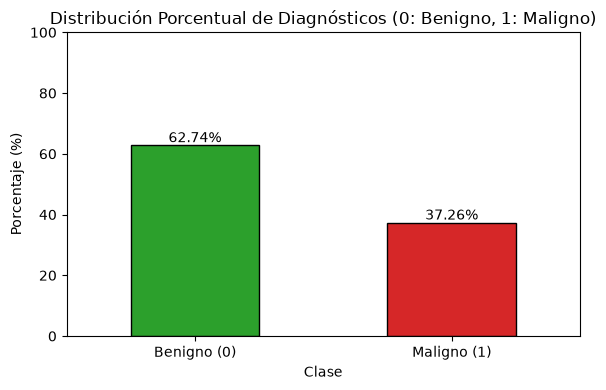

In [15]:
#Distribucion en procentaje
distribucion_porcentual = df_breast_copia['diagnosis'].value_counts(normalize=True) * 100

print("Distribución porcentual de la variable 'diagnosis':")
for clase, porcentaje in distribucion_porcentual.items():
    nombre_clase = "Maligno (1)" if clase == 1 else "Benigno (0)"
    print(f" - {nombre_clase}: {porcentaje:.2f}%")

# Grafico
plt.figure(figsize=(6, 4))
ax = distribucion_porcentual.plot(kind='bar', color=['#2ca02c', '#d62728'], edgecolor='black')
plt.title('Distribución Porcentual de Diagnósticos (0: Benigno, 1: Maligno)')
plt.xlabel('Clase')
plt.ylabel('Porcentaje (%)')
plt.xticks(ticks=[0, 1], labels=['Benigno (0)', 'Maligno (1)'], rotation=0)

# Anotación numérica sobre cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Podemos ver como en los registros , mas de la mitad presentan ser 0 , osea benignos. Esto puede decirnos que el dataser tiene una carga hacia casos de diagnosis negativa (osea tumores no malignos)

### Analsisis de los tipos de datos en el data y correlacion con la variable target

Se logra ver que todas son de tipo numerico 

In [16]:
# Exponemos el nivel de correlación entre la columna a predecir ('diagnosis') y las predictoras
# Calculamos la correlación y la ordenamos de mayor a menor
correlacion_diagnosis = df_breast_copia.corr()['diagnosis'].sort_values(ascending=False)
#Se reguardan las columnas en correlacion_diagnosis para luego analizarlas


print("Correlación de las variables predictoras con 'diagnosis':\n")
print(correlacion_diagnosis)

Correlación de las variables predictoras con 'diagnosis':

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fract

Generamos un grafico de barras para tener una mejor visualizacion

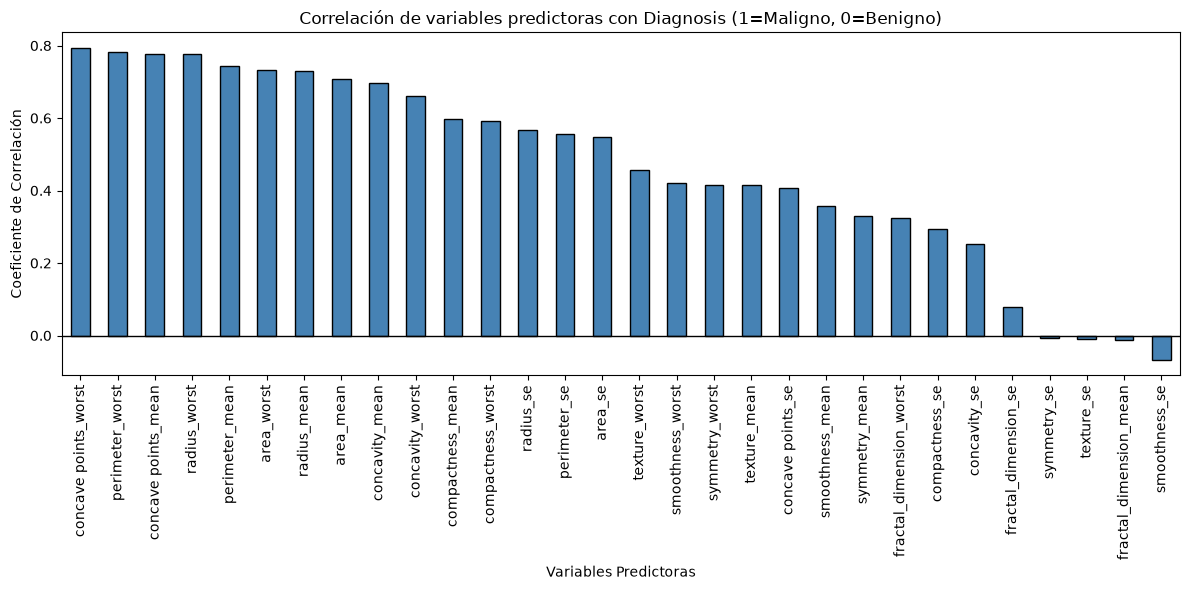

In [17]:
# 5.Visualización gráfica de la correlación de las variables predictoras
plt.figure(figsize=(12, 6))
# Se excluye la propia variable 'diagnosis' (que tendría correlación 1.0) para el gráfico
correlacion_diagnosis.drop('diagnosis').plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Correlación de variables predictoras con Diagnosis (1=Maligno, 0=Benigno)')
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Variables Predictoras')
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

Se logra observar que la gran mayoria de columnas tienen correlacion con el target, pero hay algunas que tienen negativa, igualemnte son muy pocas para influir sinificaticamente, ademas el dataset presenta indicios de multicolinealidad debido a los multiples variaciobles que miden la celula


Matriz de Correlación:
                         diagnosis  radius_mean  texture_mean  perimeter_mean  \
diagnosis                 1.000000     0.730029      0.415185        0.742636   
radius_mean               0.730029     1.000000      0.323782        0.997855   
texture_mean              0.415185     0.323782      1.000000        0.329533   
perimeter_mean            0.742636     0.997855      0.329533        1.000000   
area_mean                 0.708984     0.987357      0.321086        0.986507   
smoothness_mean           0.358560     0.170581     -0.023389        0.207278   
compactness_mean          0.596534     0.506124      0.236702        0.556936   
concavity_mean            0.696360     0.676764      0.302418        0.716136   
concave points_mean       0.776614     0.822529      0.293464        0.850977   
symmetry_mean             0.330499     0.147741      0.071401        0.183027   
fractal_dimension_mean   -0.012838    -0.311631     -0.076437       -0.261477   
radi

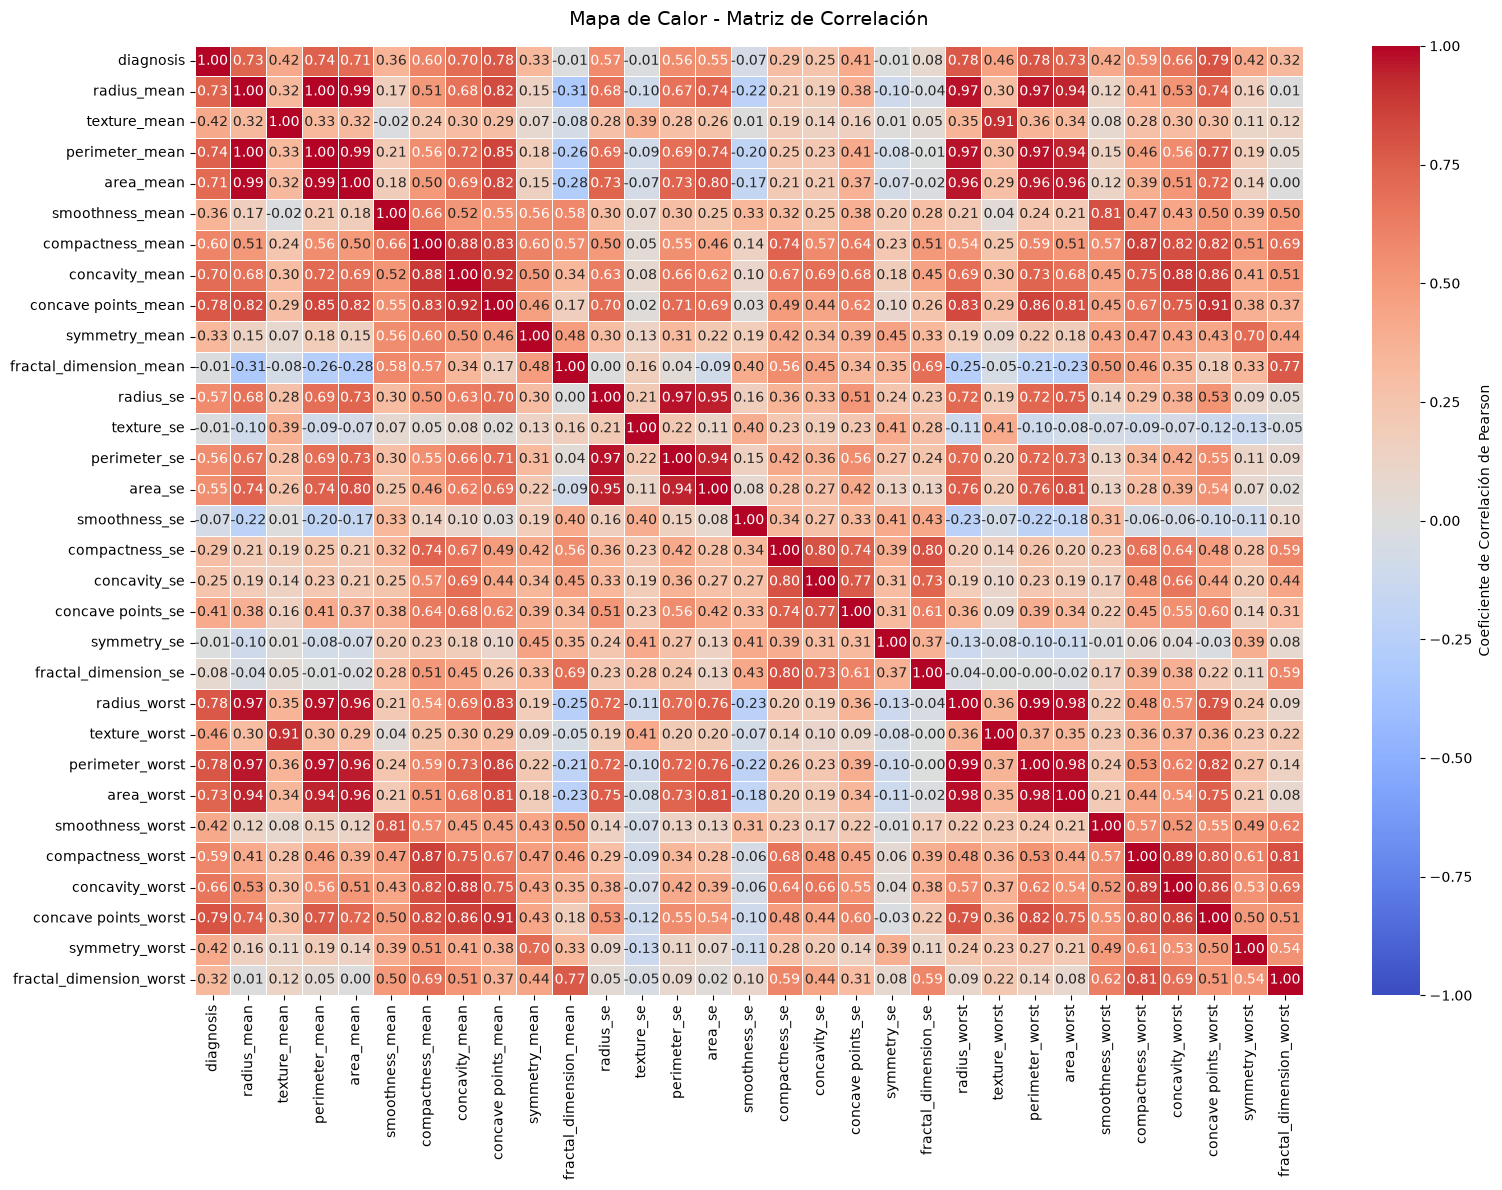

In [18]:
matriz_correlacion = df_breast_copia.corr()

# Mostramos la matriz en texto (opcional)
print("\nMatriz de Correlación:")
print(matriz_correlacion)

# Generamos el mapa de calor (Heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra el valor numérico en cada celda
    fmt=".2f",           # Limita a 2 decimales para que sea legible
    cmap='coolwarm',     # Gradiente de azul (negativo) a rojo (positivo)
    vmin=-1, vmax=1,     # Escala de correlación estandarizada
    linewidths=0.5, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Calor - Matriz de Correlación', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Se logra ver de que hay una cantidad considerable variables altamente relacionadas. Esto termina generando un problema de multicolinealidad

## Analisis de multicolinealidad

"La multicolinealidad es un fenómeno estadístico que ocurre cuando dos o más variables independientes en un modelo de regresión están altamente correlacionadas, lo que significa que una puede predecirse linealmente a partir de las demás con un grado sustancial de precisión."

En este caso se puede visualizar en las columas que guardan distintas mediciones tinene informacion relacionada, especificamente el area, perimetro y rango, que son medidas del espacio que usa un objeto,

### Uso de area como unico paramatro de medicion

Para prevenir el fenomeno anteriormente descrito, se ocupara solamente la variables que gaurden el area, esto debido a que una de las princpales formas de detecar si el tumor en maligno o el paciente presentara cancer.

El área tambien mide la totalidad del espacio bidimensional que ocupa la masa de la célula. Cuando una célula muta y comienza a generar un bulto anormal, es todo su cuerpo el que exige más espacio físico. El área es capaz de capturar esa magnitud total, entregando un número que representa fielmente el tamaño completo de la anomalía.

Procedemos a eleminar las columnas que no sean el area.

In [19]:
# Identificamos todas las columnas que contengan 'radius' o 'perimeter' en su nombre
columnas_geometria_basica = [col for col in df_breast_copia.columns if 'radius' in col or 'perimeter' in col]

# Eliminamos estas columnas del DataFrame filtrado (el que ya tenía solo _mean y _worst)
df_limpio = df_breast_copia.drop(columns=columnas_geometria_basica)

print("Columnas eliminadas (Radio y Perímetro):")
for col in columnas_geometria_basica:
    print(f" - {col}")

print(f"\nCantidad de columnas restantes listas para el VIF: {df_limpio.shape[1]}")

Columnas eliminadas (Radio y Perímetro):
 - radius_mean
 - perimeter_mean
 - radius_se
 - perimeter_se
 - radius_worst
 - perimeter_worst

Cantidad de columnas restantes listas para el VIF: 25


## Justificacion de mantener variables "worst" y "se"

El desarrollo de este modelo predictivo conserva las variables correspondientes al error estándar y a los peores valores debido a que capturan comportamientos biológicos cruciales que los promedios generales (_mean) suelen diluir.

Error Estándar (_se) para detectar la heterogeneidad tumoral: El error estándar cuantifica el nivel de desigualdad y caos dentro de la misma muestra de tejido del paciente. Un tejido benigno presenta células uniformes y ordenadas, lo que resulta en una variación cercana a cero. Por el contrario, el desarrollo maligno es inherentemente desordenado. En otras entre mayot el error estandar 

Peor Valor (_worst) para aislar anomalías extremas: Esta métrica corresponde a la media de los tres valores más grandes encontrados para cada característica en la imagen digitalizada de la mama. Su función principal es exponer la gravedad actual y localizada del tejido. Al enfocarse exclusivamente en las células más irregulares de la muestra. En otras palabras esta variable nos muestra que tan grave esta el paciente

## Inflacion de varianza (VIF)

"Un factor de inflación de varianza (VIF) proporciona una medida de multicolinealidad entre las variables independientes en un modelo de regresión múltiple. Mide cuánto se infla la varianza de una estimación de coeficiente debido a la multicolinealidad. "

In [20]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Aislar únicamente las variables predictoras (excluimos el target 'diagnosis')
# Eliminamos temporalmente los valores nulos si los hay, ya que VIF requiere datos completos
X = df_breast.drop(columns=['diagnosis']).dropna()

# 2. Crear un DataFrame vacío para estructurar los resultados en una tabla
vif_data = pd.DataFrame()
vif_data["Variable Predictora"] = X.columns

# 3. Calcular el VIF iterando por el índice de cada columna de la matriz de características
# Al usar X.values, pasamos los datos como un arreglo matemático puro
vif_data["Valor VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Ordenar los resultados de mayor a menor para detectar los casos más graves
vif_data = vif_data.sort_values(by="Valor VIF", ascending=False).reset_index(drop=True)

print("Factor de Inflación de Varianza (VIF) Con el dataset original:")
print(vif_data)

Factor de Inflación de Varianza (VIF) Con el dataset original:
        Variable Predictora    Valor VIF
0               radius_mean  3806.464754
1            perimeter_mean  3786.400488
2              radius_worst   799.418629
3           perimeter_worst   405.023630
4                 area_mean   347.968386
5                area_worst   337.319359
6                 radius_se    75.653561
7            concavity_mean    70.785037
8              perimeter_se    70.363596
9       concave points_mean    60.060406
10         compactness_mean    50.527114
11                  area_se    41.688437
12        compactness_worst    37.010829
13     concave points_worst    36.791231
14          concavity_worst    31.971022
15  fractal_dimension_worst    18.863976
16            texture_worst    18.570023
17   fractal_dimension_mean    15.759755
18             concavity_se    15.699567
19           compactness_se    15.378147
20             texture_mean    11.901803
21        concave points_se    11.5

Se logra ver de que antes del tratemiento presenta bastante variacion. Osea que quiere decir que hay variables que terminan siendo altamente redundantes en la correlacion entre variables

In [21]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Aislar únicamente las variables predictoras (excluimos el target 'diagnosis')
# Eliminamos temporalmente los valores nulos si los hay, ya que VIF requiere datos completos
X = df_limpio.drop(columns=['diagnosis']).dropna()

# 2. Crear un DataFrame vacío para estructurar los resultados en una tabla
vif_data = pd.DataFrame()
vif_data["Variable Predictora"] = X.columns

# 3. Calcular el VIF iterando por el índice de cada columna de la matriz de características
# Al usar X.values, pasamos los datos como un arreglo matemático puro
vif_data["Valor VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Ordenar los resultados de mayor a menor para detectar los casos más graves
vif_data = vif_data.sort_values(by="Valor VIF", ascending=False).reset_index(drop=True)

print("Factor de Inflación de Varianza (VIF) Con el dataset limpio:")
print(vif_data)

Factor de Inflación de Varianza (VIF) Con el dataset limpio:
        Variable Predictora  Valor VIF
0            concavity_mean  63.714355
1       concave points_mean  57.236099
2         compactness_worst  34.168224
3      concave points_worst  33.579946
4           concavity_worst  31.519447
5          compactness_mean  28.375536
6                 area_mean  25.140127
7                area_worst  21.095159
8   fractal_dimension_worst  18.230336
9             texture_worst  17.689321
10           compactness_se  14.809190
11             concavity_se  14.312045
12   fractal_dimension_mean  12.286236
13             texture_mean  11.429871
14         smoothness_worst  10.606075
15        concave points_se   9.324117
16           symmetry_worst   9.054238
17     fractal_dimension_se   8.824678
18          smoothness_mean   7.721225
19                  area_se   5.088292
20              symmetry_se   4.905420
21            symmetry_mean   4.050443
22               texture_se   3.942788
23 

Los numeros han disminuido signifivamente , esto ayudara a prevenir el fenomeno de la multicolinelidad y mejorar el rendimiento del modelo

## Analisis de valores Out Liers

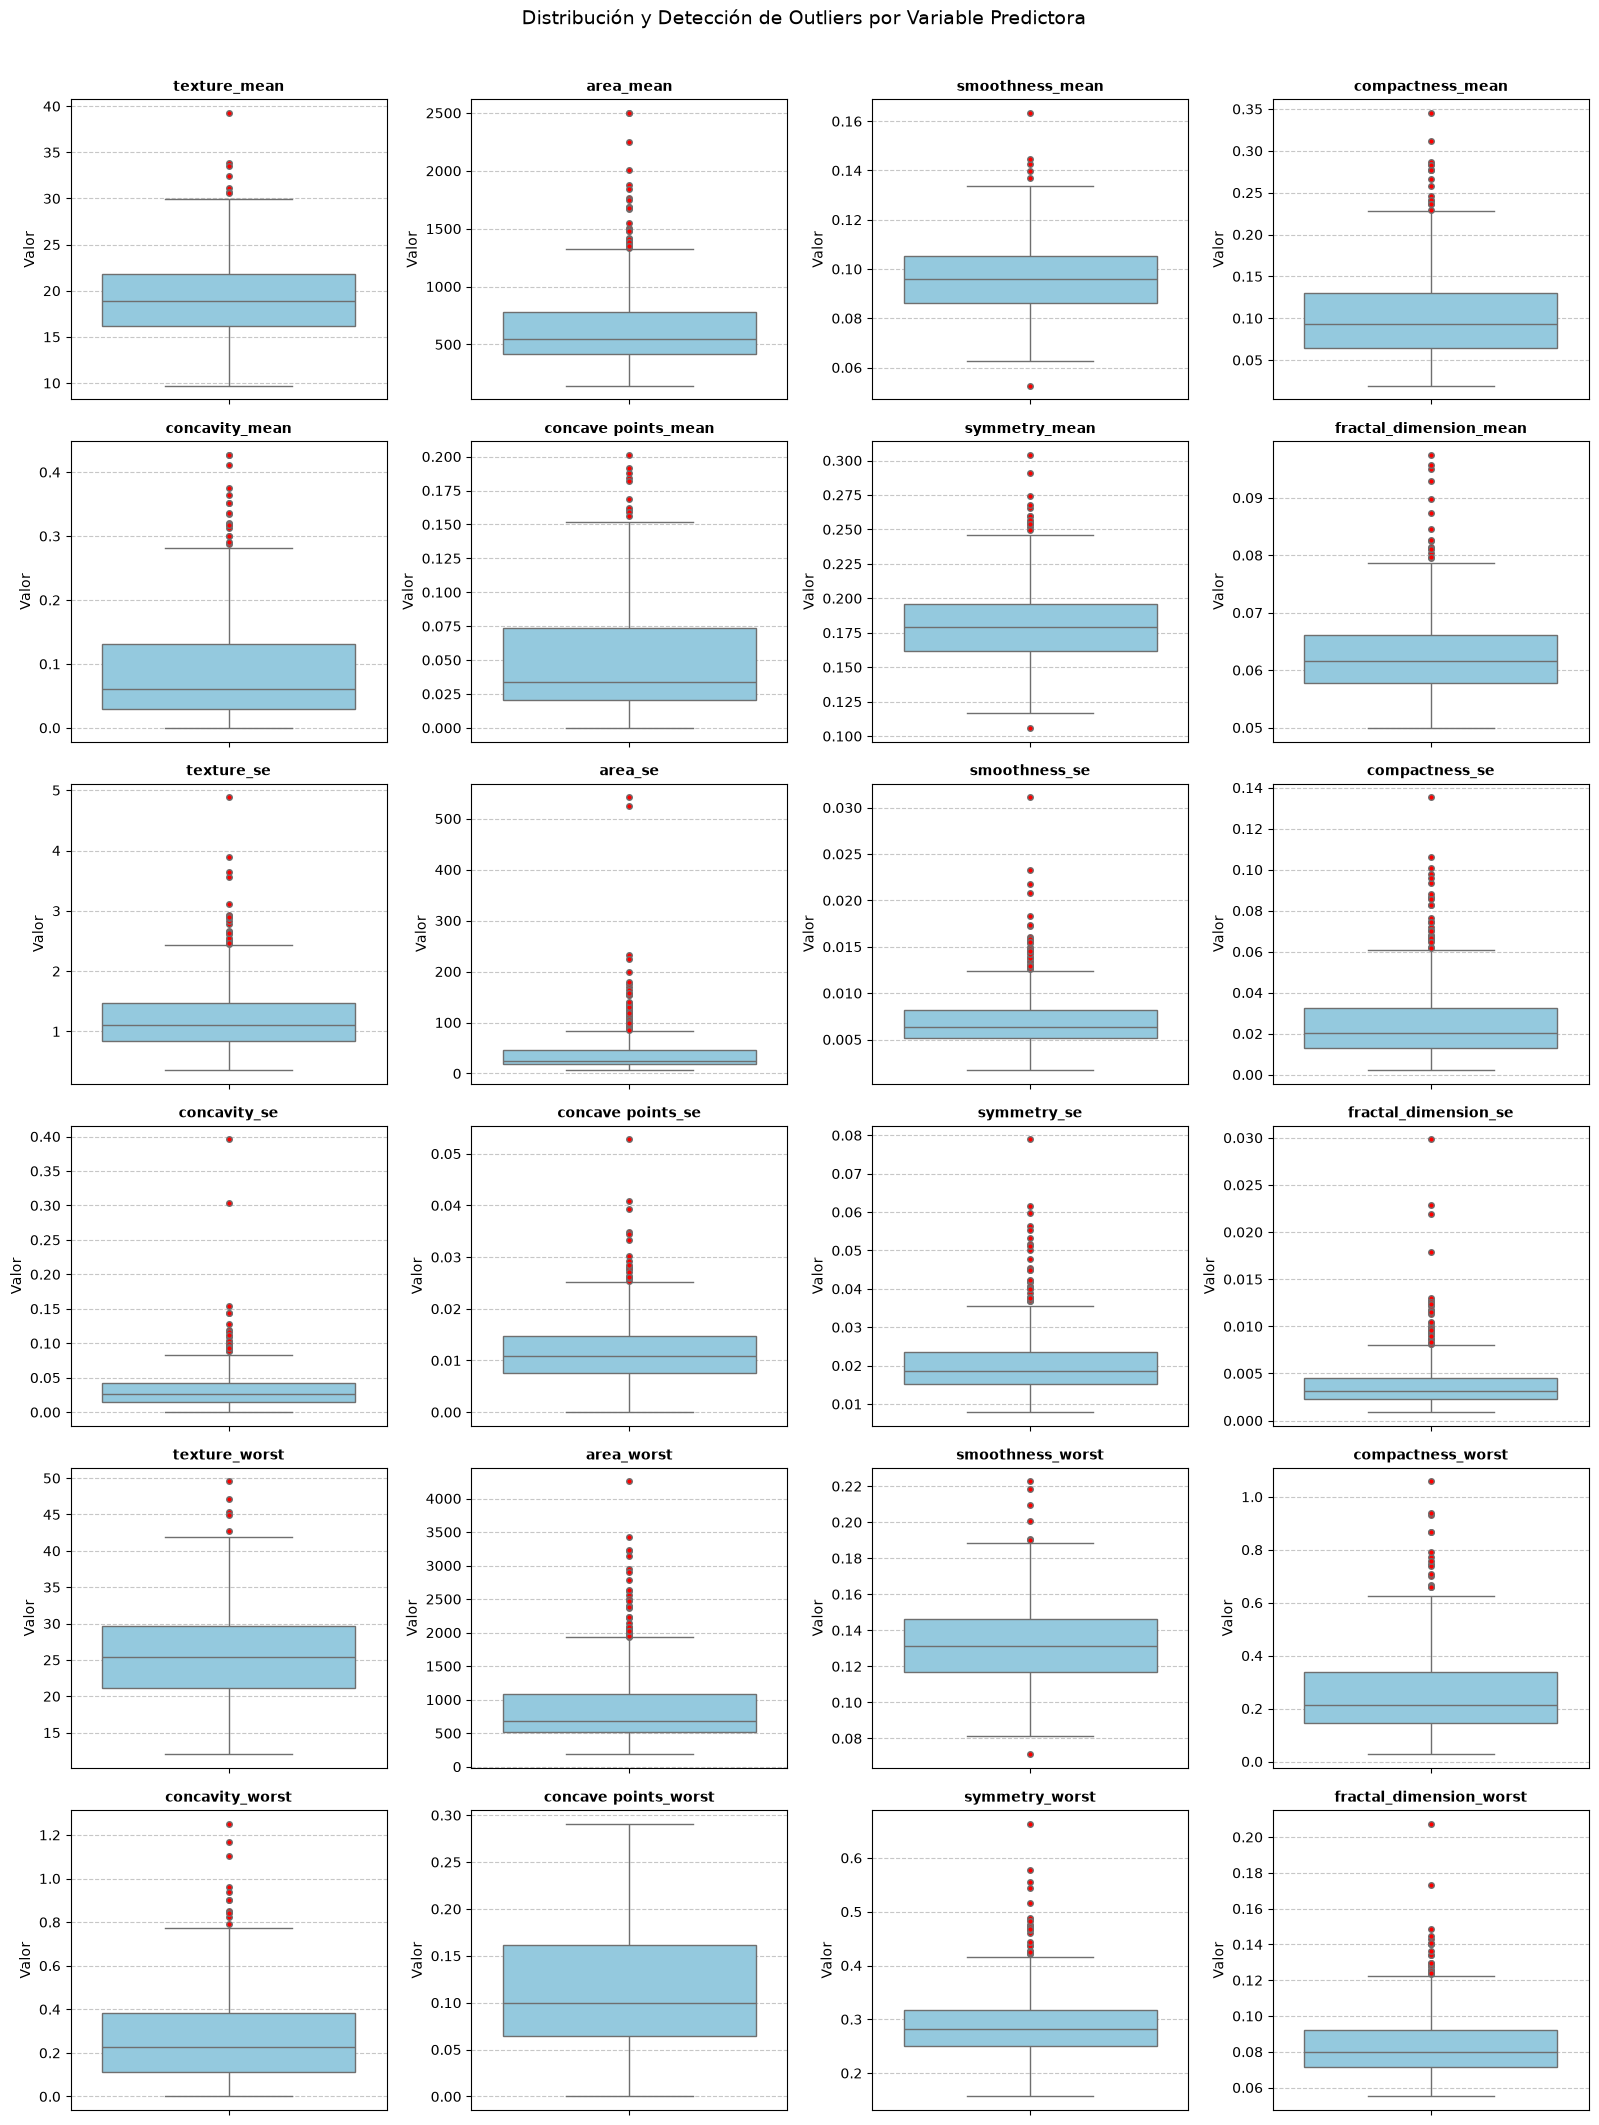

In [22]:
# Aislamos las variables pred
columnas_predictoras = [col for col in df_limpio.columns if col != 'diagnosis']

# 2. config cuadriculas
n_cols = 4  # 4 gráficos por fila
n_rows = math.ceil(len(columnas_predictoras) / n_cols)

plt.figure(figsize=(16, n_rows * 3.5))

# boxplot config
for i, col in enumerate(columnas_predictoras, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_limpio[col], color='skyblue', flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'red'})
    plt.title(col, fontsize=10, fontweight='bold')
    plt.ylabel('Valor')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribución y Detección de Outliers por Variable Predictora', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Como se logra visualizar hay registro de outliers, pero los outliers presentan la aparicion de celulas malignas, por ende no se pueden eliminar tales registros, porque o si no haria que se disminuya significativamente el dataset. **Se toma la desiscion de dejar el data set intacto en esta area**

## Comparacion de los data sets (limpio/original)

Verificamos filas eliminadas

In [23]:
print(f"Cantidad de filas original {df_breast.shape[1]}")
print(f"Cantidad de filas en el dataset limpio {df_limpio.shape[1]}")
print(f"Cantidad de filas eliminadas {df_breast.shape[1] - df_limpio.shape[1]}")

Cantidad de filas original 32
Cantidad de filas en el dataset limpio 25
Cantidad de filas eliminadas 7


## Particionamiento entrenamiento y validacion

Para entrenar el modelo separaremos los datos, como estandar se tiende a usar un 20 por ciento de los datos pra las pruebas. Con Random State hacemos que los datos vayan cambiando, pero el 42 siempre sera la misma proporcion. Con stratify hacemos que los datos mantengan la misma proporcion en la varibale target y no se dispersen de manera aleatoria

In [24]:

X = df_limpio.drop(columns=['diagnosis'])
y = df_limpio['diagnosis']

# 2. Partición: 80% entrenamiento y 20% prueba con estratificación (mantiene proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, #Tamanio de la prueba (20%)
    random_state=42, 
    stratify=y
)

Procedemos a mostrar como quedaron las pruebas y test de X y Y 

In [25]:

print(f"Cantidad de registros para X_train : {len(X_train)}")
X_train.head()

Cantidad de registros para X_train : 455


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,23.24,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,1.1870,40.51,...,0.01460,0.003042,33.88,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452
170,12.39,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,0.6656,17.43,...,0.01924,0.002248,15.64,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771
407,21.37,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,1.7980,41.24,...,0.02669,0.007731,27.01,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151
430,22.53,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.8749,24.19,...,0.01499,0.005784,27.57,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550
27,20.25,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,1.8490,93.54,...,0.02293,0.004217,27.26,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421


In [26]:

print(f"Cantidad de registros para X_test : {len(X_test)}")
X_test.head()

Cantidad de registros para X_test : 114


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,10.82,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.4607,10.50,...,0.01344,0.002206,15.97,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,23.56,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,0.8208,137.90,...,0.02401,0.005002,27.00,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.07,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.4890,14.91,...,0.01934,0.003696,19.14,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,19.77,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,1.8510,26.85,...,0.01462,0.004452,30.86,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,30.72,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,1.9240,28.93,...,0.01564,0.002985,41.61,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675


Ahora procedemos a ver como estan los datos con Y.
Y_test : 

In [27]:
print(f"Catidad de registros para y_test {len(y_test)}")
y_test.head()

Catidad de registros para y_test 114


120    0
250    1
375    0
99     1
455    0
Name: diagnosis, dtype: int64

In [28]:
print(f"Cantidad de registron para y_train: {len(y_train)}")
y_train.head()

Cantidad de registron para y_train: 455


10     1
170    0
407    0
430    1
27     1
Name: diagnosis, dtype: int64

Se a logrado visualizar y comprobar que los datos han sido extosamente separados para entrenmiento y prueba

## Evaluacion sobre escalar los datos

Procedemos a ver si es necesario escalar los datos en caso de las magnitudes de las variables seas desimiles

In [29]:
# Generamos la tabla descriptiva transpuesta (.T) para facilitar la lectura
resumen_escalas = X_train.describe().T[['min', 'mean', 'std', 'max']]

# Renombramos para claridad
resumen_escalas.columns = ['Mínimo', 'Media', 'Desv. Estándar', 'Máximo']
print(resumen_escalas)

                             Mínimo       Media  Desv. Estándar      Máximo
texture_mean               9.710000   19.417692        4.290653    39.28000
area_mean                143.500000  659.578242      360.418686  2501.00000
smoothness_mean            0.062510    0.095993        0.014310     0.16340
compactness_mean           0.019380    0.103835        0.053910     0.34540
concavity_mean             0.000000    0.089184        0.081698     0.42680
concave points_mean        0.000000    0.049015        0.039686     0.20120
symmetry_mean              0.106000    0.181497        0.027646     0.30400
fractal_dimension_mean     0.050240    0.062715        0.006971     0.09744
texture_se                 0.360200    1.217882        0.552312     4.88500
area_se                    6.802000   41.279103       48.384174   542.20000
smoothness_se              0.001713    0.006895        0.002855     0.03113
compactness_se             0.002252    0.025323        0.017624     0.10640
concavity_se

Procedemos a verlo de manera grafica

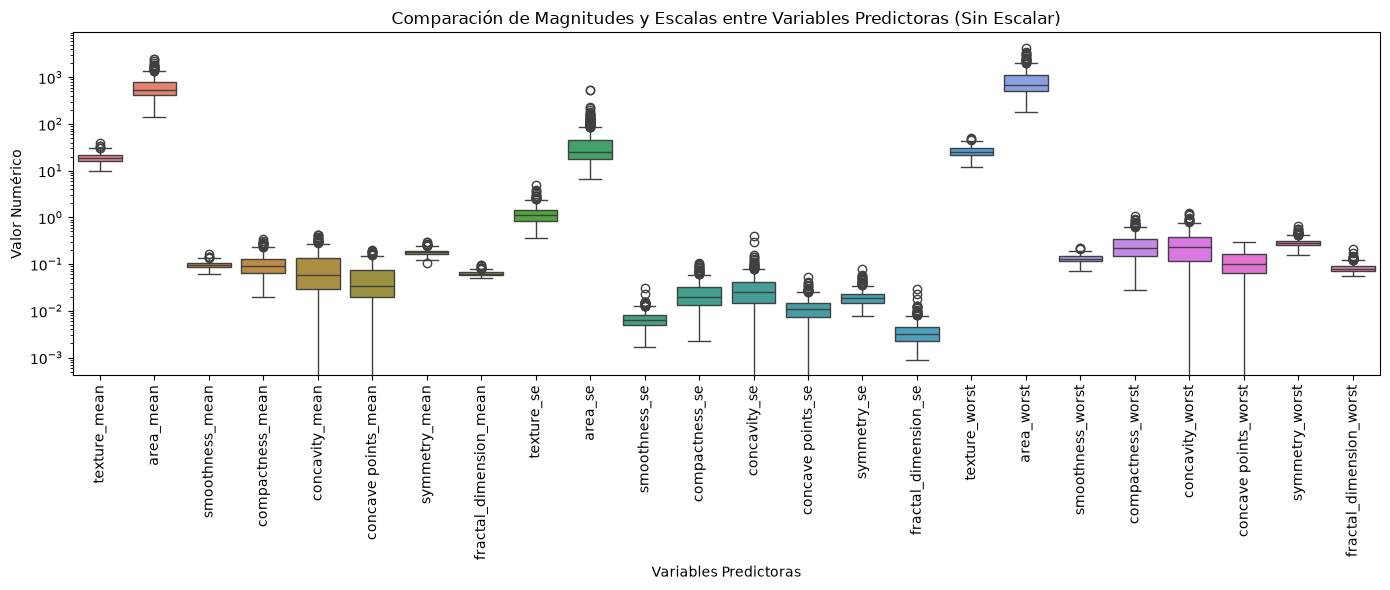

In [30]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.title('Comparación de Magnitudes y Escalas entre Variables Predictoras (Sin Escalar)')
plt.ylabel('Valor Numérico')
plt.xlabel('Variables Predictoras')
plt.yscale('log')  # Escala logarítmica para evidenciar que abarcan varios órdenes de magnitud
plt.tight_layout()
plt.show()

Se logra visualizar de que hay variables con una mayor magnitud, para que el modelo no tenga una "preferencia" o carga hacia alguna variable **es necesario escalar para prevenir que el modelo tenga sesgos**

## Escalamiento de los datos

Se procede a aplicar el MinMaxScaler()

In [31]:
# 3. Escalado correcto (DESPUÉS de separar)
scaler = MinMaxScaler()

# Se calcula el min/max SOLO con el conjunto de entrenamiento y se transforma
X_train_scaled = scaler.fit_transform(X_train)

# Se transforma el conjunto de prueba usando el min/max aprendido de X_train (sin volver a calcular .fit)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled[0]

array([0.45755834, 0.27753977, 0.1937754 , 0.1451138 , 0.07729616,
       0.16515905, 0.23636364, 0.14258475, 0.18272631, 0.06295877,
       0.07872999, 0.06737527, 0.02780303, 0.14379617, 0.09452918,
       0.07418156, 0.5826226 , 0.23712151, 0.30991217, 0.1240019 ,
       0.11653355, 0.34278351, 0.27261975, 0.19336219])

In [33]:
X_test_scaled[0]

array([0.03753805, 0.11020148, 0.30944593, 0.14560456, 0.08228679,
       0.13036779, 0.30656566, 0.23072034, 0.02221093, 0.00690701,
       0.14709182, 0.12518723, 0.03823232, 0.12237166, 0.07820679,
       0.04529939, 0.10527719, 0.07994986, 0.55226837, 0.2054021 ,
       0.16789137, 0.30783505, 0.28602405, 0.19801915])

## Modelo de regresion logistica

EL modelo de regresion logistica es un tipo de algoritmo de clasificación que predice un resultado discreto o categórico, ideal apra nuestro caso de estudio

In [34]:
modelo_logistico = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

Procedemos a entrenar el modelo

In [35]:
modelo_logistico.fit(X_train_scaled, y_train)

# 3. Confirmación en consola
print("Modelo de Regresión Logística entrenado con éxito.")
print(f"Clases aprendidas por el modelo: {modelo_logistico.classes_}")

Modelo de Regresión Logística entrenado con éxito.
Clases aprendidas por el modelo: [0 1]


Logramos ver que el modelo aprendio si 0 y 1 , osea si es maligno o no

## Reporte de clasificacion

In [36]:
#Guardamos los valores de test escalados
y_pred = modelo_logistico.predict(X_test_scaled)


reporte = classification_report(
    y_test, 
    y_pred, 
    target_names=['Benigno (0)', 'Maligno (1)'],
    digits=4
)

print("Classification Report - Regresión Logística:")
print(reporte)

Classification Report - Regresión Logística:
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



## Interpretacion del reporte de clasificacion

Podemos ver que el modelo fue capaz de predecir mas de un 90% de los de los pacientes que realemnte lo eran (precision), en benigno con 0.97 y maligno con un 1 , osea osea presento un muy buen rendimiento. la cosa cambia al no contar los falsos negativos , aca el modelo tubo mejor puntaje en los casos benignos. como proemedio en ambas categorias el modelo tuvo arriba de 95%

## Verificacion de overfitting

Debido a que los resultados estan demasiado buenos, corraboraremos que no haya sobreajuste o overfitting. para ello comparamos con lo que ecactitud en la prueba y en el entrenamiento

In [37]:
y_pred_train = modelo_logistico.predict(X_train_scaled)
acc_train = accuracy_score(y_train, y_pred_train)


y_pred_test = modelo_logistico.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Exactitud en Entrenamiento (Train): {acc_train * 100:.2f}%")
print(f"Exactitud en Prueba (Test):         {acc_test * 100:.2f}%")
print(f"Diferencia (Brecha):                 {abs(acc_train - acc_test) * 100:.2f}%")

Exactitud en Entrenamiento (Train): 96.04%
Exactitud en Prueba (Test):         98.25%
Diferencia (Brecha):                 2.20%


la brecha es muy baja , se descarta posibilidad de sobreajuste

## Matriz de confusion

Procedemos a hacer la matriz de confusion, el cual nos deja ver de una manera mas exacta como es que el modelo fue prediciendo 

In [38]:
matriz_confusion = confusion_matrix(y_test, y_pred)

Grafico de la matriz

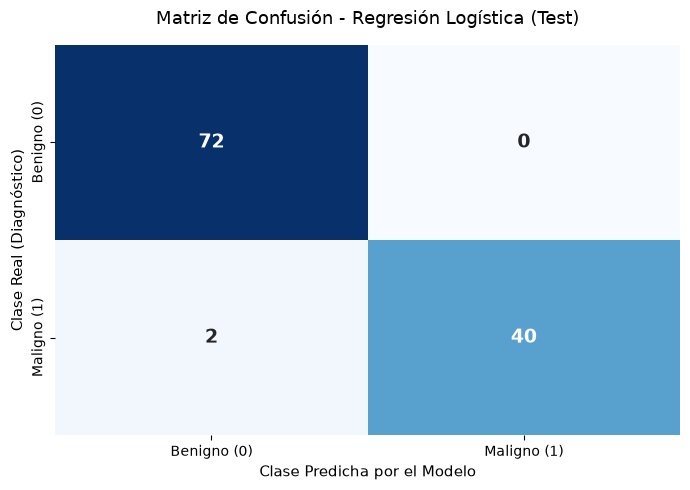

In [39]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Regresión Logística (Test)', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Modelo', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

Generenamos un desglose en consola para leer mejor los numeros

In [40]:
tn, fp, fn, tp = matriz_confusion.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp}")

Verdaderos Negativos (TN - Benignos correctos): 72
Falsos Positivos      (FP - Falsa alarma):        0
Falsos Negativos      (FN - Cáncer no detectado): 2
Verdaderos Positivos  (TP - Malignos correctos): 40


El modelo se equivoco muy poco, se destaca la gran mayoria de predicciones se encuentran en los verdaderos positivos y en los verdadaros negativos. En lo que respecta a falsos aciertos solo tuvo 2 falsos negativos, un margen de error bajisimo

## Curva Roc

In [41]:
# vemos las predicciones
y_probs = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# tasa de falsos positivos y falso negativos
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc_score = roc_auc_score(y_test, y_probs)

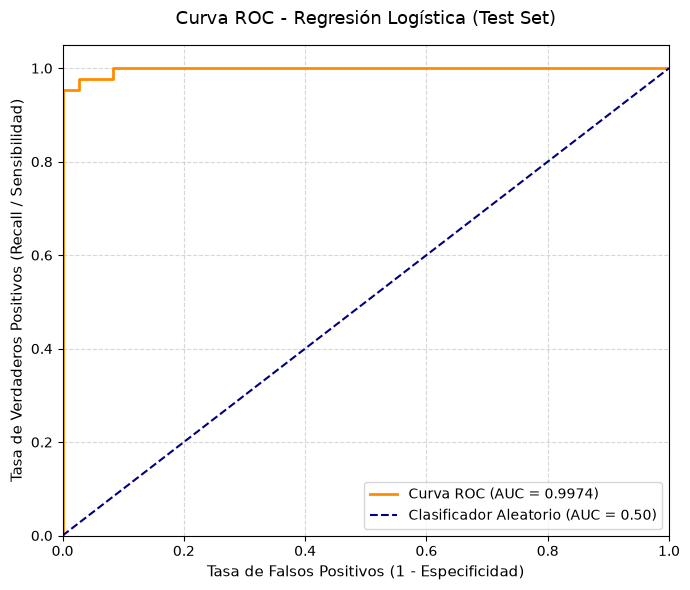

Área Bajo la Curva ROC (AUC): 0.9974


In [42]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=11)
plt.title('Curva ROC - Regresión Logística (Test Set)', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {auc_score:.4f}")

Se interpreta que el modelo tiene el rendimiento es muy bueno , esto debido a que curva de aprendizaje se aleja completamente de la aleatoriedad, si nos fijamos en los numeros dados, podemos que ver que el area es del 0.9974, entre ams cerca del 1 mejor

## Haciendo uso de la técnica GridSearchCV


**GridSearchCV es una herramienta de optimización de hiperparámetros**  en machine learning que busca de forma exhaustiva la mejor combinación de parámetros para un modelo, utilizando validación cruzada (Cross-Validation).
En un modelo de regresión, su función principal es probar todas las combinaciones posibles de hiperparámetros que tú le indiques y medir cuál de ellas reduce al mínimo el error de predicción o maximiza una métrica de desempeño específica.

In [43]:
#Definicion del de los parametros para gridSeachCV
param_grid = {
    'max_iter': [50, 100, 150, 200],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

In [44]:
#Configutacion del GridSeachDV

grid_search = GridSearchCV(
    estimator=modelo_logistico,
    param_grid=param_grid, #Aca se guarda la varible de la casilla anterior
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

Para ejecutar la busqueda , usaremos los datos escalados para no generar sesgos tambien

In [45]:
grid_search.fit(X_train_scaled, y_train)

/home/gabriel/Escritorio/Encargo ML 2/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/gabriel/Escritorio/Encargo ML 2/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/gabriel/Escritorio/Encargo ML 2/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/gabriel/Escritorio/Encargo ML 2/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_iter': [50, 100, ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

## Resultados de GridSeachCV

Procedemos a ver cuales fueron los mejores paramtros 

In [46]:

print("=== Resultados de GridSearchCV ===")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en CV (Train): {grid_search.best_score_ * 100:.2f}%\n")

=== Resultados de GridSearchCV ===
Mejores hiperparámetros: {'max_iter': 50, 'solver': 'newton-cg'}
Mejor Accuracy en CV (Train): 95.38%



Procedemos a entrenar el modelo con la configuracion anterior

In [48]:
mejor_modelo_logistico = grid_search.best_estimator_
y_pred_grid = mejor_modelo_logistico.predict(X_test_scaled)

print("Classification Report con el Mejor Modelo (Test Set):")
print(classification_report(y_test, y_pred_grid, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

Classification Report con el Mejor Modelo (Test Set):
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



Podemos ver que los resultados son similares con el modelo sin esta configuracion, entregando valorees muy positivos

## Comparacion de modelos con diferentes parametros

Ahora se compara los resutlados, para evaluar si es que las metricas difieren significativamente 

In [49]:

#Guardamos los resutlados de ambos modelos
y_pred_base = modelo_logistico.predict(X_test_scaled) #Sin grid
y_pred_grid = mejor_modelo_logistico.predict(X_test_scaled) # Cin grid

Mostramos la metrica del modelo base, osea sin GridSearchCV

In [50]:
print("=" * 65)
print("  MODELO BASE (solver='lbfgs', max_iter=1000)")
print("=" * 65)
print(classification_report(y_test, y_pred_base, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

  MODELO BASE (solver='lbfgs', max_iter=1000)
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



Mostramos la metrica del modelo base, osea **con GridSearchCV**

In [51]:
print("=" * 65)
print("  MODELO OPTIMIZADO GridSearchCV (best_estimator_)")
print(f"  Parámetros: {grid_search.best_params_}")
print("=" * 65)
print(classification_report(y_test, y_pred_grid, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

  MODELO OPTIMIZADO GridSearchCV (best_estimator_)
  Parámetros: {'max_iter': 50, 'solver': 'newton-cg'}
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



Para tener una mejor visulizacion generamos una tabla comparativa

In [ ]:
acc_base = accuracy_score(y_test, y_pred_base)
acc_grid = accuracy_score(y_test, y_pred_grid)

cm_base = confusion_matrix(y_test, y_pred_base)
cm_grid = confusion_matrix(y_test, y_pred_grid)

# Extracción de Verdaderos Positivos (TP) y Falsos Negativos (FN) de la clase 1 (Maligno)
tp_base, fn_base = cm_base[1, 1], cm_base[1, 0]
tp_grid, fn_grid = cm_grid[1, 1], cm_grid[1, 0]

tabla_comparativa = pd.DataFrame({
    'Métrica': ['Accuracy Global', 'Recall Maligno (1)', 'Falsos Negativos (FN)', 'Verdaderos Positivos (TP)'],
    'Modelo Base (lbfgs)': [f"{acc_base * 100:.2f}%", f"{(tp_base / (tp_base + fn_base)) * 100:.2f}%", fn_base, tp_base],
    'Modelo GridSearchCV': [f"{acc_grid * 100:.2f}%", f"{(tp_grid / (tp_grid + fn_grid)) * 100:.2f}%", fn_grid, tp_grid]
})

tabla_comparativa #Imprimmos los resultados

,Métrica,Modelo Base (lbfgs),Modelo GridSearchCV
0,Accuracy Global,98.25%,98.25%
1,Recall Maligno (1),95.24%,95.24%
2,Falsos Negativos (FN),2,2
3,Verdaderos Positivos (TP),40,40


Podemos ver que entre ambos modelos, tinen resultados identicos. **Se llega a la conclusion que el modelo se mantiene**

## Modelo de arbol de desicion 

Un decision tree es un algoritmo de aprendizaje supervisado no paramétrico, que se utiliza tanto para tareas de clasificación como de regresión. Tiene una estructura jerárquica, de árbol, que consta de un nodo raíz, ramas, nodos internos y nodos de hoja.

In [56]:
#Guardamos el arbol de desicion
arbol_decision = DecisionTreeClassifier(max_depth=3, random_state=0)

In [57]:
arbol_decision.fit(X_train_scaled, y_train)

y_pred_arbol = arbol_decision.predict(X_test_scaled)

exactitud_arbol = accuracy_score(y_test, y_pred_arbol)

## Metricas del arbol de desicion

Verficamos la exactitud del modelo

In [58]:

exactitud_arbol = accuracy_score(y_test, y_pred_arbol)

print("=== Evaluación del Árbol de Decisión ===")
print(f"Precisión global (Accuracy Score): {exactitud_arbol:.4f} ({exactitud_arbol * 100:.2f}%)")


=== Evaluación del Árbol de Decisión ===
Precisión global (Accuracy Score): 0.9474 (94.74%)


Generamos el reporte de clasificacion para ver con mas detalle

In [59]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))


Classification Report:
              precision    recall  f1-score   support

 Benigno (0)     0.9231    1.0000    0.9600        72
 Maligno (1)     1.0000    0.8571    0.9231        42

    accuracy                         0.9474       114
   macro avg     0.9615    0.9286    0.9415       114
weighted avg     0.9514    0.9474    0.9464       114



Se logra ver que el modelo tiene porblemas acertando celulas malignas, se refleja en recall.

## Modelo de arbol de desiscion sin restriccion

Se construye el modelo sin profundidad

In [60]:
arbol_decision_sin_rest = DecisionTreeClassifier( random_state=0)

Al igual que con el arbol anterior se va a entrenar, poner a prueba y guardar resultados en la misma casilla

In [61]:
arbol_decision_sin_rest.fit(X_train_scaled, y_train)

y_pred_arbol = arbol_decision_sin_rest.predict(X_test_scaled)

exactitud_arbol = accuracy_score(y_test, y_pred_arbol)

## Metricas de arbol de desicion sin restriccion

In [62]:

exactitud_arbol = accuracy_score(y_test, y_pred_arbol)

print("=== Evaluación del Árbol de Decisión sin rest ===")
print(f"Precisión global (Accuracy Score): {exactitud_arbol:.4f} ({exactitud_arbol * 100:.2f}%)")

=== Evaluación del Árbol de Decisión sin rest ===
Precisión global (Accuracy Score): 0.9298 (92.98%)


Se logra ver que el puntaje fue un poco peor que con restriccion

In [63]:
print("\nClassification Report , Sin restriccion: ")
print(classification_report(y_test, y_pred_arbol, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))


Classification Report , Sin restriccion: 
              precision    recall  f1-score   support

 Benigno (0)     0.9324    0.9583    0.9452        72
 Maligno (1)     0.9250    0.8810    0.9024        42

    accuracy                         0.9298       114
   macro avg     0.9287    0.9196    0.9238       114
weighted avg     0.9297    0.9298    0.9294       114



A comparacion del modelo anterior con restriccion de profundidad, se vea un peor rendimiento para celulas benignas o malignas en todas los puntajes

## Verificacion de overfiting

Se procede a revisar si ambos modelos presentan overfitting a travez de dos metodos. Comparacion de rendimiento en el entrenamiento y en la prueba con la curva de validacion

## Verificacion de exactitud de entrenamiento vs prueba 

In [64]:
acc_train = arbol_decision.score(X_train_scaled, y_train)
acc_test = arbol_decision.score(X_test_scaled, y_test)

print(f"Accuracy en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train - acc_test) * 100:.2f}%")

Accuracy en Entrenamiento: 96.48%
Accuracy en Prueba:        94.74%
Brecha (Diferencia):       1.75%


La brecha es muy baja en el arbol con restriccion, no hay overfitting
Pasamos a virualizar la curva de aprendizaje

In [68]:
acc_train = arbol_decision_sin_rest.score(X_train_scaled, y_train)
acc_test = arbol_decision_sin_rest.score(X_test_scaled, y_test)

print(f"Accuracy en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train - acc_test) * 100:.2f}%")

Accuracy en Entrenamiento: 100.00%
Accuracy en Prueba:        92.98%
Brecha (Diferencia):       7.02%


La brecha a aumentado significativamente, hay indicios de un sobre ajuste debido a que en el entrenamiento se tuvo un puntaje perfecto

## Verificacion de overfitting con la curva de validacion por profundidad

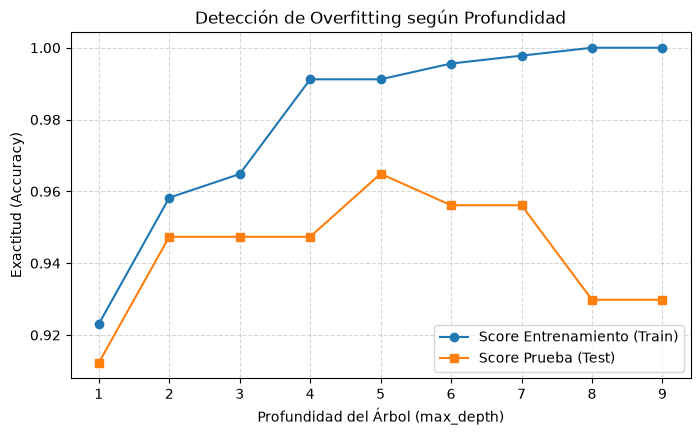

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

profundidades = range(1, 10) 
train_scores = []
test_scores = []

for d in profundidades:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf.fit(X_train_scaled, y_train)
    train_scores.append(clf.score(X_train_scaled, y_train))
    test_scores.append(clf.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(profundidades, train_scores, label='Score Entrenamiento (Train)', marker='o')
plt.plot(profundidades, test_scores, label='Score Prueba (Test)', marker='s')
plt.xlabel('Profundidad del Árbol (max_depth)')
plt.ylabel('Exactitud (Accuracy)')
plt.title('Detección de Overfitting según Profundidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

En este grafico se logra visulizar de que solo hay overfitting pasado el limite establecido de profundidad, osea despues del 3. Eso quiere decur que **el arbol sin limite de profundidad tiene o tendra overfiting**

## Grafico de los arboles de desicion 

Procedemos a ver la forma de los arboles generados, los nodos aranjados corresponden son los casos benignos y azulados malignos

Arbol de desicion con restriccion

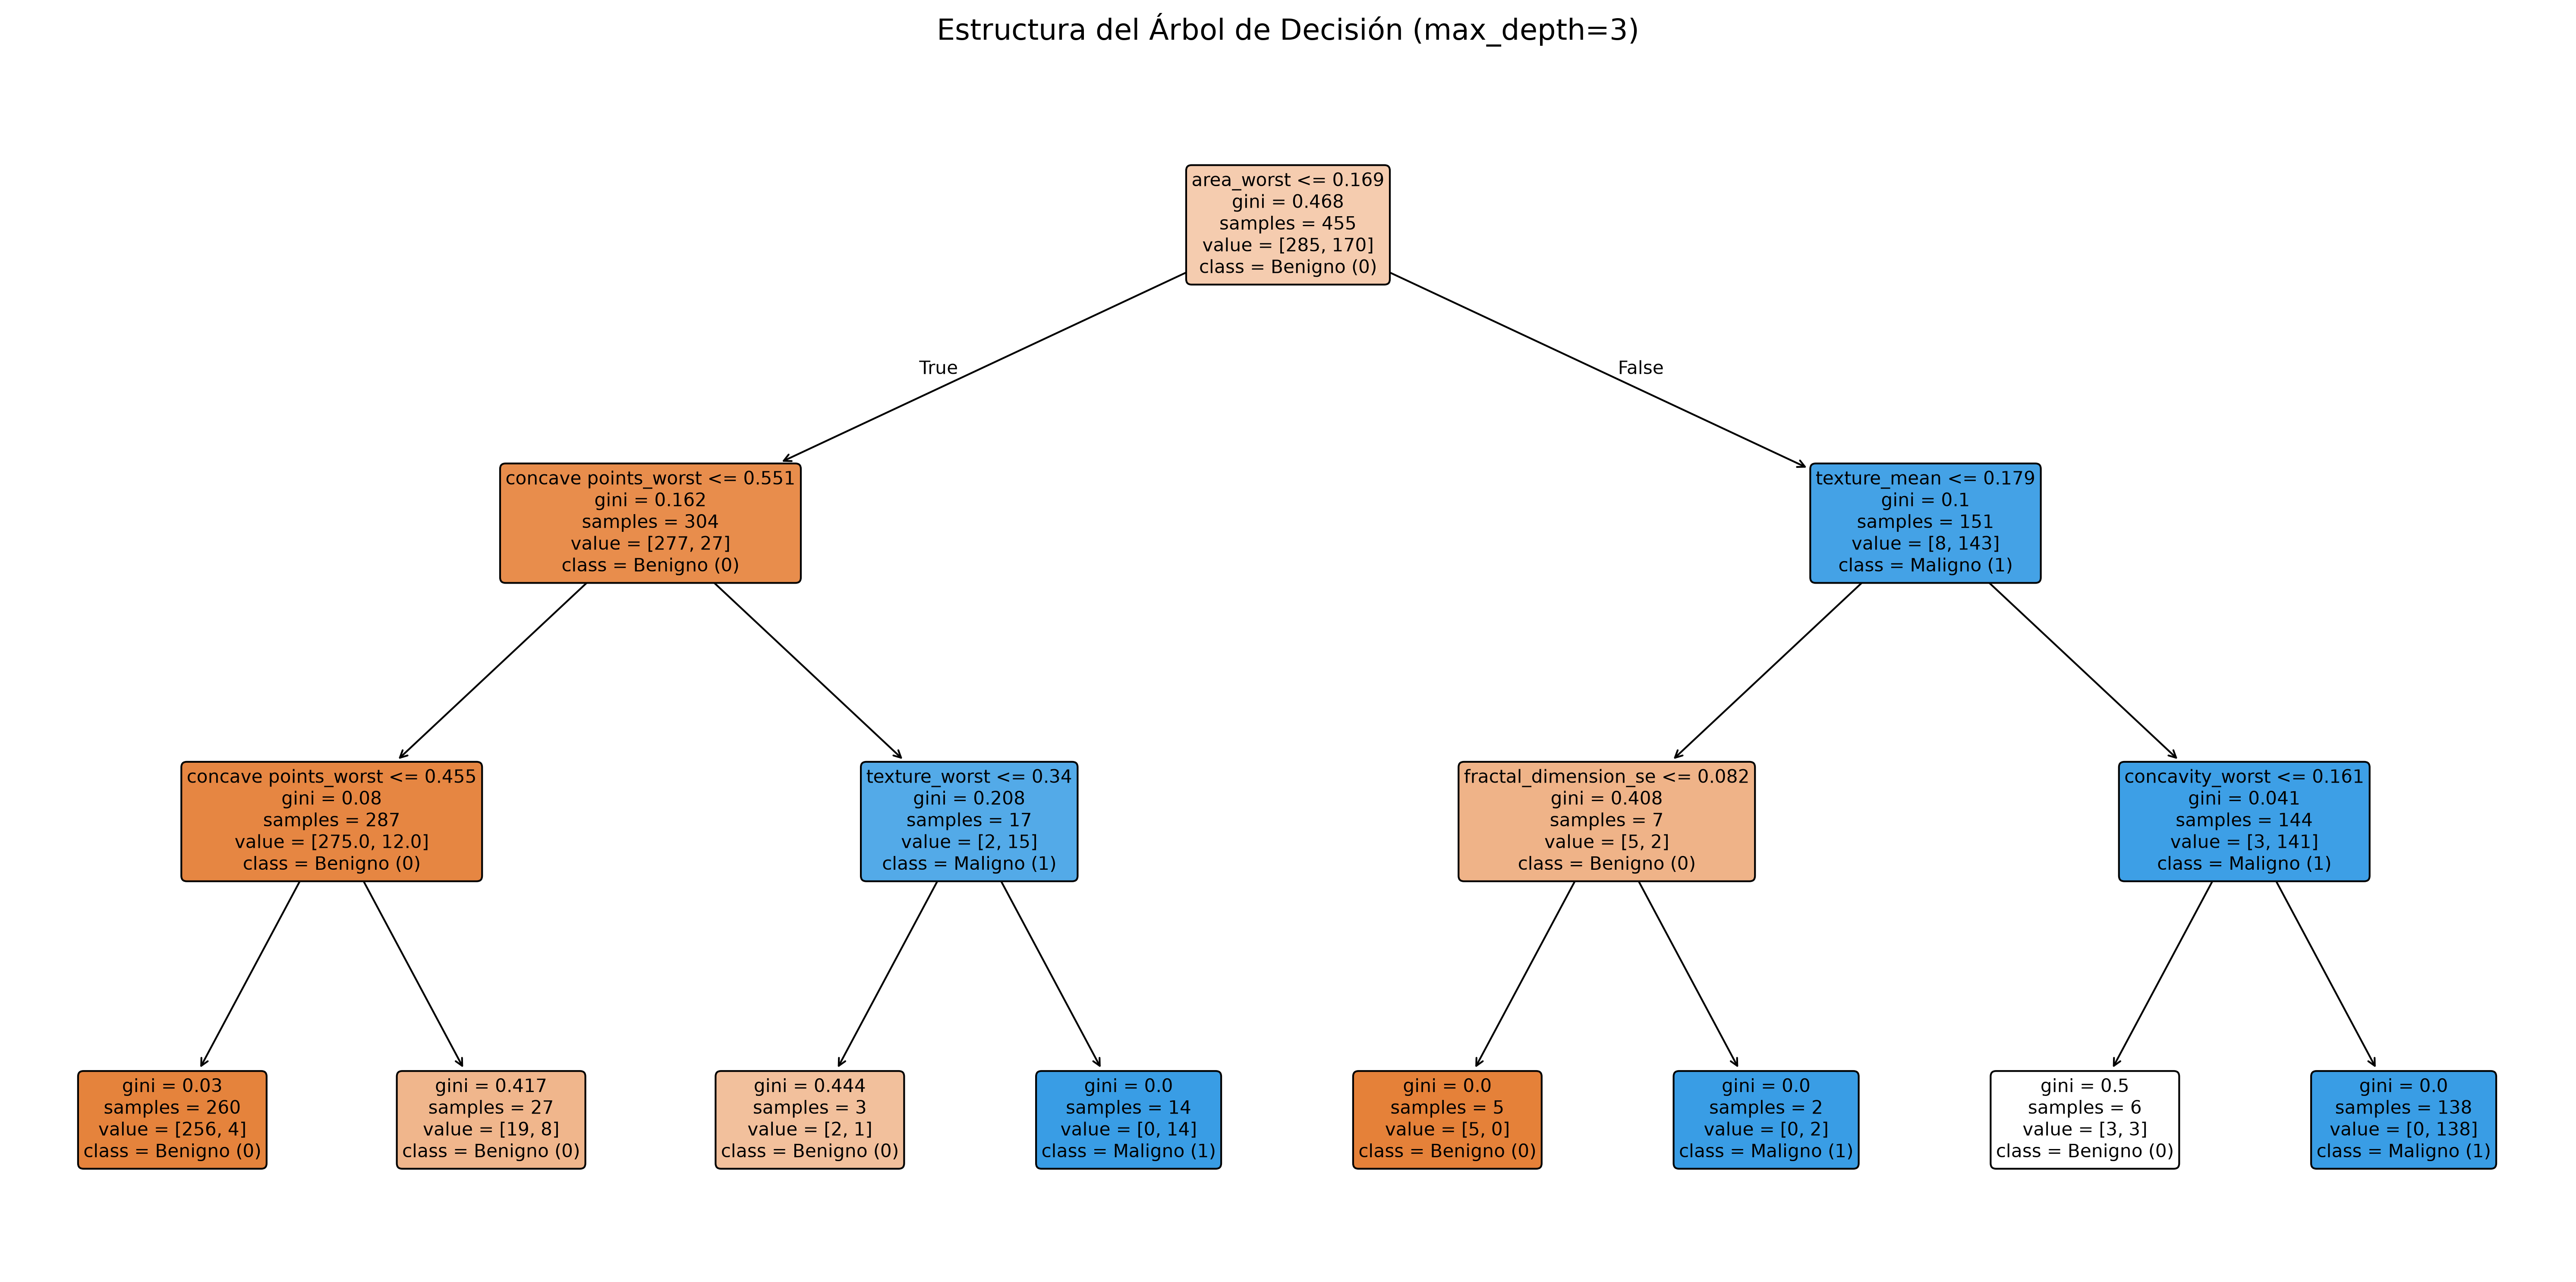

In [70]:
#config
plt.figure(figsize=(20, 10), dpi=300)


plot_tree(
    arbol_decision, #Arbol de desision con rest
    feature_names=X.columns,
    class_names=['Benigno (0)', 'Maligno (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=3
)

plt.title("Estructura del Árbol de Decisión (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

arbol de desision sin restriccion

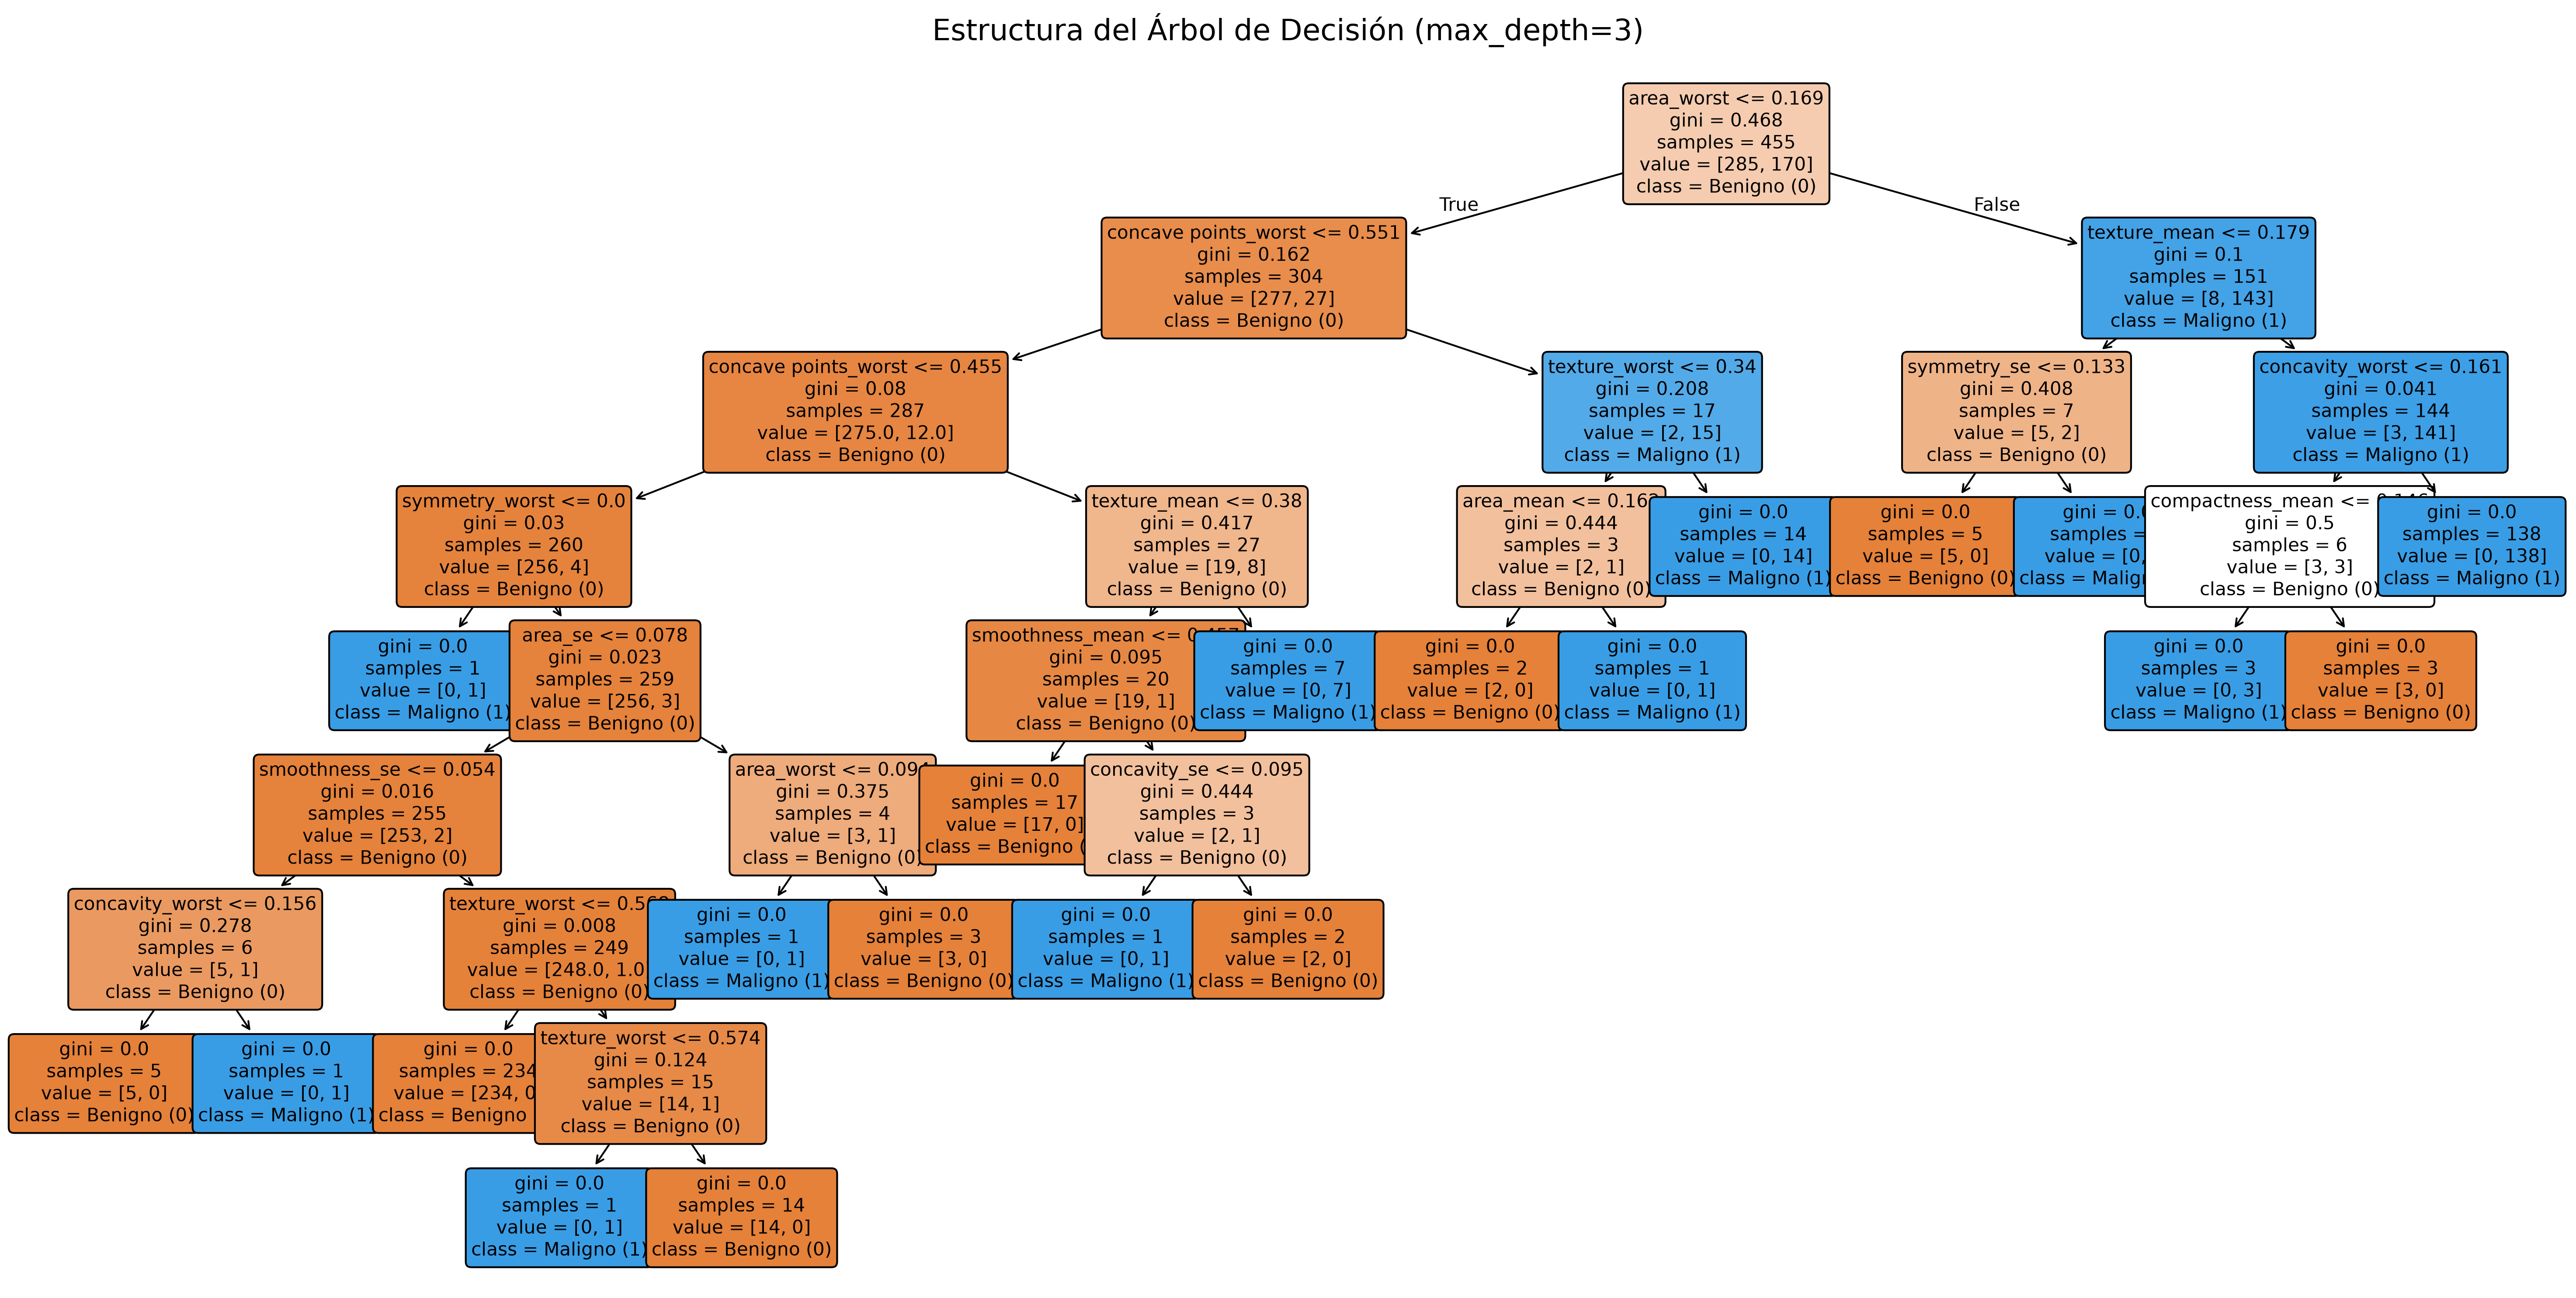

In [71]:
#config
plt.figure(figsize=(20, 10), dpi=300)


plot_tree(
    arbol_decision_sin_rest,
    feature_names=X.columns,
    class_names=['Benigno (0)', 'Maligno (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=3
)

plt.title("Estructura del Árbol de Decisión (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Se logra ver que en el caso del arbol sin restriccion la cantidad nodos por el lado de verdadero es mucho mayor, esto posiblemente por la diferencia de pacientes belignos y malignos en el dataset

## Interpretacion de las metricas

## ¿Qué interpretación se puede dar a los valores de Accuracy, Precision, Recall, F1-score y ROC-AUC?

Primero visualizamos los resultados del arbol de desicion

In [74]:

y_pred_arbol = arbol_decision.predict(X_test_scaled)
y_probs_arbol = arbol_decision.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_arbol)
prec = precision_score(y_test, y_pred_arbol, pos_label=1)
rec = recall_score(y_test, y_pred_arbol, pos_label=1)
f1 = f1_score(y_test, y_pred_arbol, pos_label=1)
roc_auc = roc_auc_score(y_test, y_probs_arbol)

# 3. Presentar los resultados en una tabla estructurada
metricas_arbol = pd.DataFrame({
    'Métrica Descriptor': [
        'Accuracy (Exactitud Global)',
        'Precision (Precisión - Maligno)',
        'Recall (Sensibilidad - Maligno)',
        'F1-Score (Balance Armónico)',
        'ROC-AUC (Área Bajo la Curva)'
    ],
    'Valor Numérico': [acc, prec, rec, f1, roc_auc],
    'Porcentaje': [f"{acc * 100:.2f}%", f"{prec * 100:.2f}%", f"{rec * 100:.2f}%", f"{f1 * 100:.2f}%", f"{roc_auc * 100:.2f}%"]
})

print("=" * 60)
print("  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)")
print("=" * 60)
print(metricas_arbol.to_string(index=False))

  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)
             Métrica Descriptor  Valor Numérico Porcentaje
    Accuracy (Exactitud Global)        0.947368     94.74%
Precision (Precisión - Maligno)        1.000000    100.00%
Recall (Sensibilidad - Maligno)        0.857143     85.71%
    F1-Score (Balance Armónico)        0.923077     92.31%
   ROC-AUC (Área Bajo la Curva)        0.986938     98.69%


El modelo tiene buenas predicciones , especificamente en la exactitud global nos muestra que pudo acertar un 94% de los datos que eran benignos y malignos. Lueho en la presicion en lo que respecta a celular malignas tubo un acierto del 100%.  donde tuvo peor rendimineto fue en Recall cpm 85.71%, en el cual en los casos malignos muestra que hubieron falsos positivos o negativos involucdrados. Por ultimo el area bajo la curva nos muestra que el modelo esta lejos de la aleatoriedad

Ahora visualizamos el arbol de desicion **sin restriccion**

In [75]:
y_pred_arbol = arbol_decision_sin_rest.predict(X_test_scaled)
y_probs_arbol = arbol_decision_sin_rest.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_arbol)
prec = precision_score(y_test, y_pred_arbol, pos_label=1)
rec = recall_score(y_test, y_pred_arbol, pos_label=1)
f1 = f1_score(y_test, y_pred_arbol, pos_label=1)
roc_auc = roc_auc_score(y_test, y_probs_arbol)

# 3. Presentar los resultados en una tabla estructurada
metricas_arbol = pd.DataFrame({
    'Métrica Descriptor': [
        'Accuracy (Exactitud Global)',
        'Precision (Precisión - Maligno)',
        'Recall (Sensibilidad - Maligno)',
        'F1-Score (Balance Armónico)',
        'ROC-AUC (Área Bajo la Curva)'
    ],
    'Valor Numérico': [acc, prec, rec, f1, roc_auc],
    'Porcentaje': [f"{acc * 100:.2f}%", f"{prec * 100:.2f}%", f"{rec * 100:.2f}%", f"{f1 * 100:.2f}%", f"{roc_auc * 100:.2f}%"]
})

print("=" * 60)
print("  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)")
print("=" * 60)
print(metricas_arbol.to_string(index=False))

  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)
             Métrica Descriptor  Valor Numérico Porcentaje
    Accuracy (Exactitud Global)        0.929825     92.98%
Precision (Precisión - Maligno)        0.925000     92.50%
Recall (Sensibilidad - Maligno)        0.880952     88.10%
    F1-Score (Balance Armónico)        0.902439     90.24%
   ROC-AUC (Área Bajo la Curva)        0.919643     91.96%


El modelo presenta un rendimiento general aceptable, donde la exactitud globa nos muestra que logró clasificar correctamente un 92.98% de los casos totales entre benignos y malignos.Luego, en la precisión orientada a la detección de células malignas, alcanzó un 92.50%, lo que indica que cuando el árbol clasifica un tumor como maligno comete pocas falsas alarmas (falsos positivos).

Donde mostró su punto más bajo fue en el Recall, marcando un 88.10% en la clase maligna. Esto evidencia que el modelo dejó escapar cerca de un 12% de casos con cáncer real al clasificarlos erróneamente como benignos (falsos negativos), siendo esta la debilidad crítica en un contexto de diagnóstico oncológico.

El F1-Score (90.24%) confirma un equilibrio general adecuado entre precisión y sensibilidad, mientras que el área bajo la curva (ROC-AUC de 91.96%) demuestra que el modelo mantiene una buena capacidad de discriminación diagnóstica, situándose significativamente lejos de la aleatoriedad.

### ¿Mejora la precisión esta vez con el conjunto de entrenamiento y con el conjunto de pruebas?


Para verificarlo se correran de nuevo los codigos que mostraban la diferencia en la exactitud 

In [80]:
#Con restriccion
acc_train = arbol_decision.score(X_train_scaled, y_train)
acc_test = arbol_decision.score(X_test_scaled, y_test)

#Sin restriccion
acc_train_sin = arbol_decision_sin_rest.score(X_train_scaled, y_train)
acc_test_sin = arbol_decision_sin_rest.score(X_test_scaled, y_test)

print(f"Accuracy en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train - acc_test) * 100:.2f}%")

print(f"------Sin restriccion-------")

print(f"Accuracy en Entrenamiento: {acc_train_sin * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test_sin * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train_sin - acc_test_sin) * 100:.2f}%")

Accuracy en Entrenamiento: 96.48%
Accuracy en Prueba:        94.74%
Brecha (Diferencia):       1.75%
------Sin restriccion-------
Accuracy en Entrenamiento: 100.00%
Accuracy en Prueba:        92.98%
Brecha (Diferencia):       7.02%


Al responder directamente a la pregunta, se observa un comportamiento opuesto entre ambos conjuntos: en el conjunto de entrenamiento, la precisión no mejora con la restricción, sino que disminuye del 100.00% al 96.48%; sin embargo, en el conjunto de pruebas ocurre lo verdaderamente importante, ya que la precisión sí mejora, subiendo del 92.98% al 94.74%.

Este fenómeno demuestra con claridad el impacto de la regularización. En el modelo sin restricción, alcanzar un 100% en entrenamiento a costa de caer a un 92.98% en prueba genera una brecha del 7.02%, lo que evidencia un claro sobreajuste (overfitting) donde el árbol memorizó particularidades y ruido de la muestra. En contraste, al limitar la profundidad (max_depth=3), el modelo sacrifica la memorización perfecta en el entrenamiento para ganar capacidad de generalización frente a datos nuevos no vistos, reduciendo la brecha a solo un 1.75% y logrando un clasificador clínicamente más confiable y robusto.

### Matriz de confusion

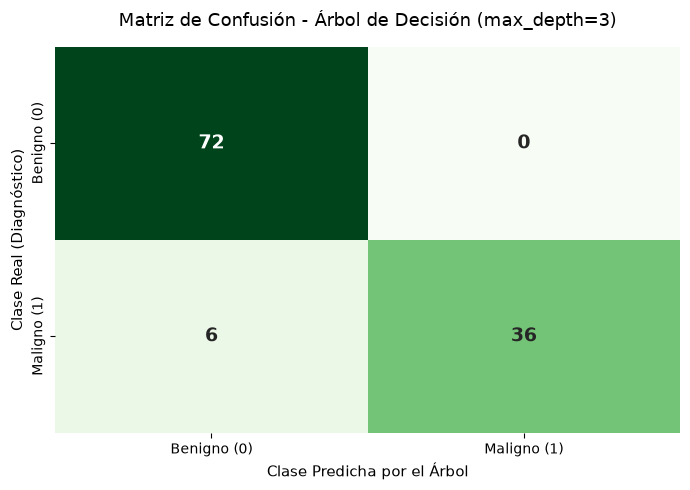

Verdaderos Negativos (TN - Benignos correctos): 72
Falsos Positivos      (FP - Falsa alarma):        0
Falsos Negativos      (FN - Cáncer no detectado): 6
Verdaderos Positivos  (TP - Malignos correctos): 36


In [ ]:

y_pred_arbol = arbol_decision.predict(X_test_scaled)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_arbol, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Árbol de Decisión (max_depth=3)', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Árbol', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_arbol.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp}")

El modelo con restriccio solo tienefalsos negativos con las celulas benignas, lo demas tuvo excelente rendimineto

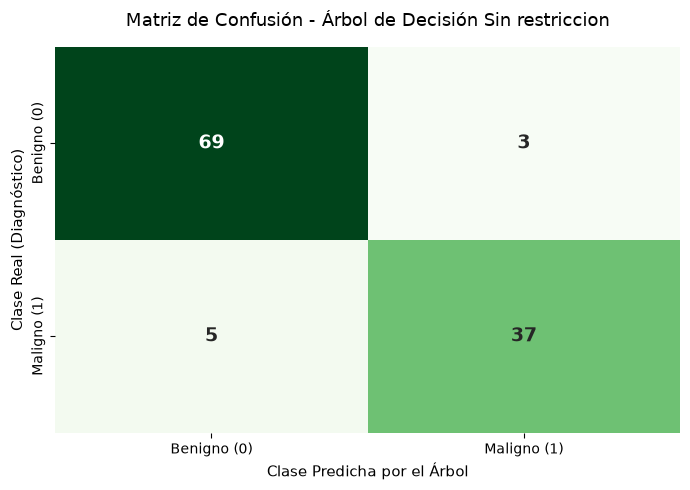

Verdaderos Negativos (TN - Benignos correctos): 69
Falsos Positivos      (FP - Falsa alarma):        3
Falsos Negativos      (FN - Cáncer no detectado): 5
Verdaderos Positivos  (TP - Malignos correctos): 37


In [82]:

y_pred_arbol = arbol_decision_sin_rest.predict(X_test_scaled)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_arbol, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Árbol de Decisión Sin restriccion', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Árbol', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_arbol.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp}")

A diferencia del modelo con restriccion de profundidad , tiene una mayor cantidad de falsos positivos y negativos

**Se llega la conclusion de que el modelo sin restriccion es el mejor**

## Fuentes

https://medium.com/@azizozmen/understanding-multicollinearity-its-impact-on-data-analysis-and-machine-learning-94da6620569e

https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e